# FlashEats — Class 5 Investigation

## Client escalation

> **“Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system.”**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

In [1]:
# 0. IMPORTS
import os, sys, json, time, math, sqlite3, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# The notebook runs from the exercises folder, and the pack sits next to it.
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found at {DB_PATH.resolve()}. Run this notebook from the exercises folder.")

print("BASE:", BASE)
print("Database found:", DB_PATH.exists())

BASE: FlashEats_Classroom_Pack_V2
Database found: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | It is the promise stored with the order. Dispatch also has `current_delivery_eta`, but that is a live estimate that moves, not the promise. |
| Actual delivery time | `orders.actual_delivery_at` (SQLite) | Order system of record. `driver_events.json` has a `delivered` event I can use to cross-check it. |
| Driver assignment | Dispatch API (`driver_id`, `original_driver_id`, `assigned_at`, `reassigned_at`) | Dispatch owns assignment. `orders.driver_id` may only hold one driver, so it can miss reassignments. |
| Customer complaint | `support_tickets.csv` | What the customer actually said. Context only, not a timestamp source. |
| Restaurant status | `restaurant_status.csv` | Restaurant-side status (preparing / ready / handed_off), partly updated by hand. |
| Driver movement/events | `driver_events.json` | Nested per-driver log: assigned, gps_ping, picked_up, delivered. |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

My answer: I treat the orders table as authoritative for the promise and for final status / delivery time, because that is what the customer was charged and measured on. Dispatch is authoritative for who was assigned and when. Driver events are authoritative only for what the driver app explicitly logged (assigned, picked_up, delivered); the GPS pings are a signal I would have to interpret. Support tickets and restaurant status are contextual: they tell me what people experienced or reported, but they are sparse and partly manual, so I would not compute a KPI from them alone. I check these assumptions below instead of trusting them.

In [3]:
# 3. BASIC SYNTAX — READ EVERY SOURCE

# SQLite
con = sqlite3.connect(DB_PATH)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;", con)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[0]["events"][:3])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'order_id': 'O00162',
  'type': 'assigned',
  'timestamp': '2026-08-26T17:53:25.977803'},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:10:59.372420',
  'lat': 12.826339,
  'lon': 77.448282},
 {'order_id': 'O00162',
  'type': 'gps_ping',
  'timestamp': '2026-08-26T18:28:32.767037',
  'lat': 12.876013,
  'lon': 77.477707}]

# Challenge 1 — How large is the late-delivery problem?

Before coding, decide:

- **Late means:** the order was delivered after `promised_eta`, i.e. `delay_min = actual_delivery_at - promised_eta > 0`. This is the strictest version (VP Operations). I also report `> 10 min` because Support thinks only that is "meaningfully" late.
- **Denominator:** unique `order_id`s whose status (after trimming and lower-casing) is `delivered` and that have a non-null `actual_delivery_at`.
- **Cancelled orders:** exclude from the late rate (they were never delivered, so "late" does not apply), but report how many there are.
- **Missing actual delivery timestamp:** exclude from the denominator and report the count as "unknown". I do not assume they were on time, and I do not quietly fill them from another source.
- **Row grain:** one row should be one order. I check that, because the table has more rows than order IDs.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
# Small helpers I reuse in the rest of the notebook
TS_COLS = ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]

def load_clean_orders(con):
    # clean = one row per order_id, parsed timestamps, lower-case labels, delay_min
    raw = pd.read_sql("SELECT * FROM orders", con)
    df = raw.drop_duplicates("order_id", keep="first").copy()
    for c in TS_COLS:
        df[c] = pd.to_datetime(df[c], format="mixed", errors="coerce")
    df["status"] = df["final_status"].str.strip().str.lower()
    df["traffic"] = df["traffic_bucket"].str.strip().str.lower()
    df["delay_min"] = (df["actual_delivery_at"] - df["promised_eta"]).dt.total_seconds() / 60
    return raw, df

def valid_delivered(df):
    # my denominator: delivered orders that have an actual delivery time
    return df[(df["status"] == "delivered") & df["actual_delivery_at"].notna()]

def late_rate(df, threshold=0):
    v = valid_delivered(df)
    late = int((v["delay_min"] > threshold).sum())
    return {"threshold_min": threshold, "late": late, "valid_delivered": len(v), "late_pct": round(100 * late / len(v), 1)}

raw_orders, orders = load_clean_orders(con)
print("Raw rows:", len(raw_orders), "| unique order_ids:", raw_orders["order_id"].nunique())

Raw rows: 1603 | unique order_ids: 1600


In [5]:
# Data-quality checks BEFORE computing the metric

# 1) Grain: are the duplicated order_ids identical copies?
dups = raw_orders[raw_orders["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dups[["order_id", "final_status", "promised_eta", "actual_delivery_at", "traffic_bucket"]])
differing_cols = [c for c in raw_orders.columns if dups.groupby("order_id")[c].nunique(dropna=False).max() > 1]
print("Columns that differ between duplicate copies:", differing_cols)

# 2) Status labels (raw) and missing delivery time by normalised status
print("\nRaw final_status values:", raw_orders["final_status"].value_counts().to_dict())
print("Normalised status:", orders["status"].value_counts().to_dict())
display(pd.crosstab(orders["status"], orders["actual_delivery_at"].isna().map({True: "missing actual", False: "has actual"})))

# 3) Chronology
print("promised_eta before created_at:", int((orders["promised_eta"] < orders["created_at"]).sum()))
print("actual_delivery_at before pickup_at:", int((orders["actual_delivery_at"] < orders["pickup_at"]).sum()))
print("cancelled orders that still have a pickup_at:", int((orders["status"].eq("cancelled") & orders["pickup_at"].notna()).sum()))

,order_id,final_status,promised_eta,actual_delivery_at,traffic_bucket
119,O00120,delivered,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,severe
1600,O00120,delivered,2026-08-13T19:40:24,2026-08-13T19:34:08.431508,medium
722,O00723,delivered,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,medium
1601,O00723,delivered,2026-08-05T22:19:36,2026-08-05T22:04:30.928322,high
1301,O01302,delivered,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,medium
1602,O01302,delivered,2026-08-26T22:15:50.273095,2026-08-26T22:20:27.428561,high


Columns that differ between duplicate copies: ['traffic_bucket']

Raw final_status values: {'delivered': 1530, 'cancelled': 68, 'Delivered': 5}
Normalised status: {'delivered': 1532, 'cancelled': 68}


actual_delivery_at,has actual,missing actual
status,,
cancelled,0,68
delivered,1495,37


promised_eta before created_at: 4
actual_delivery_at before pickup_at: 5
cancelled orders that still have a pickup_at: 68


In [6]:
# The metric itself
v = valid_delivered(orders)
late_orders = v[v["delay_min"] > 0]

print("Unique orders:", len(orders))
print("Cancelled (excluded):", int((orders["status"] == "cancelled").sum()))
print("Delivered but no actual_delivery_at (unknown, excluded):", int(((orders["status"] == "delivered") & orders["actual_delivery_at"].isna()).sum()))
print("Valid delivered orders:", len(v))
print(f"Late (> 0 min): {len(late_orders)} = {100 * len(late_orders) / len(v):.1f}%")
print(f"Median lateness among late orders: {late_orders['delay_min'].median():.1f} min")
print(f"Median delay across all valid delivered orders: {v['delay_min'].median():.1f} min")

threshold_table = pd.DataFrame([late_rate(orders, t) for t in [0, 5, 10, 15]])
display(threshold_table)

# flag rows whose timestamps are impossible, so the worst-case list is not taken at face value
orders["chronology_flag"] = (orders["promised_eta"] < orders["created_at"]) | (orders["actual_delivery_at"] < orders["pickup_at"])
v = valid_delivered(orders)
print("Worst 8 delayed orders:")
worst = v.nlargest(8, "delay_min")[["order_id", "restaurant_id", "traffic", "weather_bucket", "created_at", "promised_eta", "actual_delivery_at", "delay_min", "chronology_flag"]]
display(worst.assign(delay_min=worst["delay_min"].round(1)))

Unique orders: 1600
Cancelled (excluded): 68
Delivered but no actual_delivery_at (unknown, excluded): 37
Valid delivered orders: 1495
Late (> 0 min): 843 = 56.4%
Median lateness among late orders: 8.0 min
Median delay across all valid delivered orders: 1.4 min


,threshold_min,late,valid_delivered,late_pct
0,0,843,1495,56.4
1,5,560,1495,37.5
2,10,349,1495,23.3
3,15,208,1495,13.9


Worst 8 delayed orders:


,order_id,restaurant_id,traffic,weather_bucket,created_at,promised_eta,actual_delivery_at,delay_min,chronology_flag
103,O00104,R031,medium,clear,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,True
101,O00102,R004,medium,clear,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,True
100,O00101,R007,low,rain,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,True
102,O00103,R020,high,clear,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,True
1080,O01081,R048,high,clear,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,False
472,O00473,R002,high,clear,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,False
1101,O01102,R021,medium,clear,2026-08-12 18:25:00,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,45.0,False
193,O00194,R020,high,heavy_rain,2026-08-11 17:36:00,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.3,False


In [7]:
# How much do the data-quality choices move the headline number?
def pct(num, den):
    return round(100 * num / den, 1)

raw_parsed = raw_orders.copy()
for c in ["promised_eta", "actual_delivery_at"]:
    raw_parsed[c] = pd.to_datetime(raw_parsed[c], format="mixed", errors="coerce")
raw_parsed["delay_min"] = (raw_parsed["actual_delivery_at"] - raw_parsed["promised_eta"]).dt.total_seconds() / 60
raw_nonnull = raw_parsed[raw_parsed["actual_delivery_at"].notna()]
exact_lower = raw_nonnull[raw_nonnull["final_status"] == "delivered"]

v_chrono_ok = v[~v["chronology_flag"]]
delivered_all = orders[orders["status"] == "delivered"]

sensitivity = pd.DataFrame([
    {"variant": "My definition (dedup, normalised status, non-null actual)", "late": len(late_orders), "denominator": len(v)},
    {"variant": "No dedup (raw 1603 rows, non-null actual)", "late": int((raw_nonnull["delay_min"] > 0).sum()), "denominator": len(raw_nonnull)},
    {"variant": "Case-sensitive 'delivered' only (drops 'Delivered')", "late": int((exact_lower["delay_min"] > 0).sum()), "denominator": len(exact_lower)},
    {"variant": "Missing actual counted as not late (in denominator)", "late": len(late_orders), "denominator": len(delivered_all)},
    {"variant": "Also drop 9 rows with broken chronology", "late": int((v_chrono_ok["delay_min"] > 0).sum()), "denominator": len(v_chrono_ok)},
])
sensitivity["late_pct"] = pct(sensitivity["late"], sensitivity["denominator"])
display(sensitivity)

,variant,late,denominator,late_pct
0,"My definition (dedup, normalised status, non-null actual)",843,1495,56.4
1,"No dedup (raw 1603 rows, non-null actual)",844,1498,56.3
2,Case-sensitive 'delivered' only (drops 'Delivered'),841,1493,56.3
3,Missing actual counted as not late (in denominator),843,1532,55.0
4,Also drop 9 rows with broken chronology,837,1486,56.3


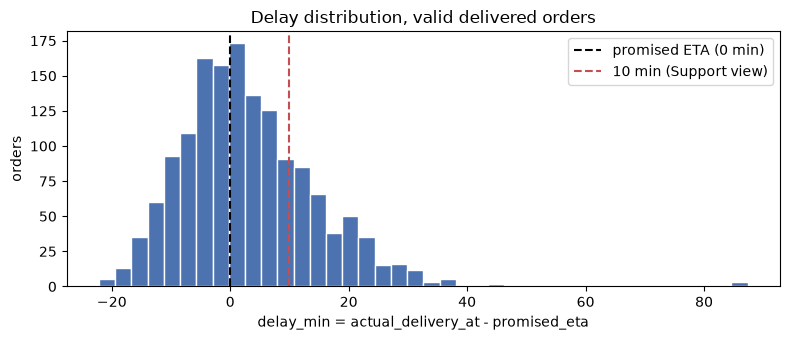

In [8]:
# Chart: distribution of delay minutes
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(v["delay_min"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", label="promised ETA (0 min)")
ax.axvline(10, color="#C44E52", linestyle="--", label="10 min (Support view)")
ax.set_xlabel("delay_min = actual_delivery_at - promised_eta")
ax.set_ylabel("orders")
ax.set_title("Delay distribution, valid delivered orders")
ax.legend()
plt.tight_layout()
plt.show()

### What I found for Challenge 1

- The orders table has 1603 rows but only 1600 unique `order_id`s. The 3 duplicated orders (O00120, O00723, O01302) are identical except for `traffic_bucket`, which is different in each copy. I kept the first copy. That does not change the late rate, but I would not trust the traffic label for those 3 orders.
- 68 orders are cancelled and 37 are "delivered" with no `actual_delivery_at`, so I am left with **1495 valid delivered orders**. The 5 rows spelled `Delivered` are included (same status, different case).
- **843 of 1495 (56.4%)** arrived after the promised ETA. Only 349 (23.3%) were more than 10 minutes late. The median lateness among late orders is 8.0 min and the median delay over all valid orders is 1.4 min, so most late orders are only a few minutes late.
- The worst-delay list needs care. The top 4 (O00104, O00102, O00101, O00103, 69 to 87 min "late") are the rows where `promised_eta` is before `created_at`, so their delay is an artefact of a broken promise time. The worst order with sane timestamps is O01081 at 50.3 min.
- Cleaning choices move the headline by about a point (55.0% to 56.4% in the sensitivity table). The definition moves it much more (56.4% vs 23.3%). The single biggest cleaning choice is the 37 missing timestamps: putting them in the denominator as "not late" gives 55.0%.
- Other things I flagged but did not fix: 5 deliveries logged before pickup, and all 68 cancelled orders still have a `pickup_at`.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

If another team gets a different number, I would compare definitions and populations before arguing about who is right. Some examples from the table above: counting raw rows gives 844 / 1498 = 56.3%, filtering on `final_status = 'delivered'` exactly gives 841 / 1493 = 56.3%, keeping the 37 missing-timestamp orders in the denominator gives 55.0%, and using the Support definition (> 10 min) gives 23.3%.

# Challenge 2 — Operations says: “Traffic is the problem.”

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2–3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [9]:
def by_dimension(df, col):
    v = valid_delivered(df)
    out = v.groupby(col, observed=True).agg(
        orders=("order_id", "count"),
        late_pct=("delay_min", lambda s: round(100 * (s > 0).mean(), 1)),
        median_delay_min=("delay_min", "median"),
    )
    return out.round(1)

# stage durations from the orders table
orders["created_to_pickup_min"] = (orders["pickup_at"] - orders["created_at"]).dt.total_seconds() / 60
orders["pickup_to_delivery_min"] = (orders["actual_delivery_at"] - orders["pickup_at"]).dt.total_seconds() / 60
orders["promise_window_min"] = (orders["promised_eta"] - orders["created_at"]).dt.total_seconds() / 60
orders["hour"] = orders["created_at"].dt.hour
orders["distance_bucket"] = pd.cut(orders["distance_km_estimate"], [0, 5, 10, 15, 17.99, 18.01, 100],
                                   labels=["0-5", "5-10", "10-15", "15-18", "exactly 18.0", "over 18"])

traffic_order = ["low", "medium", "high", "severe"]
t = by_dimension(orders, "traffic").reindex(traffic_order)
print("Traffic"); display(t)
print("Weather"); display(by_dimension(orders, "weather_bucket"))
print("Distance (km estimate)"); display(by_dimension(orders, "distance_bucket"))
print("Share of orders with distance exactly 18.0 km:", f"{(orders['distance_km_estimate'] == 18).mean():.1%}")

Traffic


,orders,late_pct,median_delay_min
traffic,,,
low,360,49.4,-0.1
medium,588,51.4,0.3
high,424,66.5,4.0
severe,123,65.9,4.3


Weather


,orders,late_pct,median_delay_min
weather_bucket,,,
clear,1192,53.3,0.8
heavy_rain,72,73.6,6.6
rain,231,67.1,4.3


Distance (km estimate)


,orders,late_pct,median_delay_min
distance_bucket,,,
0-5,69,53.6,0.6
5-10,222,55.9,1.0
10-15,300,52.7,0.6
15-18,152,63.2,2.7
exactly 18.0,749,56.7,1.4
over 18,3,100.0,26.3


Share of orders with distance exactly 18.0 km: 50.4%


In [10]:
# Where does the time go? Compare the two halves of the journey.
v = valid_delivered(orders).copy()
v["late"] = v["delay_min"] > 0
stage = v.groupby("late")[["promise_window_min", "created_to_pickup_min", "pickup_to_delivery_min"]].median().round(1)
stage.index = stage.index.map({False: "on time", True: "late"})
print("Median minutes by stage:"); display(stage)

print("Traffic vs stage durations (medians):")
display(v.groupby("traffic")[["promise_window_min", "created_to_pickup_min", "pickup_to_delivery_min"]].median().reindex(traffic_order).round(1))

v["pickup_wait_quartile"] = pd.qcut(v["created_to_pickup_min"], 4)
print("Late rate by created->pickup quartile:")
display(by_dimension(v, "pickup_wait_quartile"))

print("Correlation with delay_min:")
print(v[["created_to_pickup_min", "pickup_to_delivery_min", "distance_km_estimate"]].corrwith(v["delay_min"]).round(2))

Median minutes by stage:


,promise_window_min,created_to_pickup_min,pickup_to_delivery_min
late,,,
on time,72.8,19.8,45.3
late,74.0,31.9,48.9


Traffic vs stage durations (medians):


,promise_window_min,created_to_pickup_min,pickup_to_delivery_min
traffic,,,
low,72.8,25.8,43.5
medium,75.5,25.9,46.7
high,79.8,27.0,53.0
severe,85.4,25.5,61.8


Late rate by created->pickup quartile:


,orders,late_pct,median_delay_min
pickup_wait_quartile,,,
"(6.348, 20.397]",374,3.2,-8.4
"(20.397, 26.066]",374,37.4,-1.5
"(26.066, 33.202]",373,85.8,4.4
"(33.202, 89.176]",374,99.2,15.5


Correlation with delay_min:
created_to_pickup_min     0.83
pickup_to_delivery_min    0.21
distance_km_estimate      0.07
dtype: float64


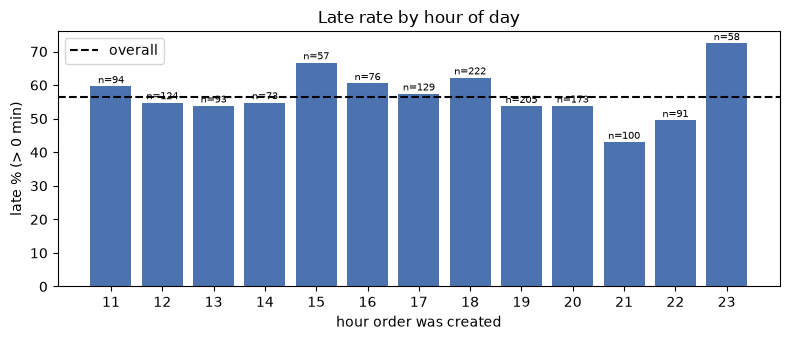

hour,11,12,13,14,15,16,17,18,19,20,21,22,23
orders,94.0,124.0,93.0,73.0,57.0,76.0,129.0,222.0,205.0,173.0,100.0,91.0,58.0
late_pct,59.6,54.8,53.8,54.8,66.7,60.5,57.4,62.2,53.7,53.8,43.0,49.5,72.4
median_delay_min,1.9,1.0,0.7,0.9,4.0,2.4,3.0,3.2,0.9,0.5,-1.5,-0.0,4.6


In [11]:
# Chart: late rate by hour of day
hourly = by_dimension(orders, "hour")
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(hourly.index.astype(str), hourly["late_pct"], color="#4C72B0")
ax.axhline(late_rate(orders)["late_pct"], color="black", linestyle="--", label="overall")
for x, (n, p) in enumerate(zip(hourly["orders"], hourly["late_pct"])):
    ax.text(x, p + 1, f"n={n}", ha="center", fontsize=7)
ax.set_xlabel("hour order was created")
ax.set_ylabel("late % (> 0 min)")
ax.set_title("Late rate by hour of day")
ax.legend()
plt.tight_layout()
plt.show()
display(hourly.T)

Traffic is associated with lateness, but I don't think it is the main cause.

- Traffic: 49.4% late in low, 51.4% medium, 66.5% high, 65.9% severe. The extra time is on the road leg (pickup to delivery 43.5 min in low vs 61.8 in severe), and the promise window already gets longer with traffic.
- Weather: rain 67.1%, heavy rain 73.6%, clear 53.3%. Heavy rain is only 72 orders and probably overlaps with traffic.
- Distance: no pattern, and 50.4% of orders are exactly 18.0 km, so I don't trust it.
- Before pickup: late orders took a median 31.9 min from creation to pickup vs 19.8 min for on-time ones. By quartile of that wait the late rate goes 3.2%, 37.4%, 85.8%, 99.2%.
- Hour of day: between 43.0% (21:00) and 72.4% (23:00), no clear rush-hour effect.

Hypothesis: most lateness builds up before pickup. Alternative I can't rule out: the wait could come from the restaurant or from dispatch sending the driver late, and the orders table can't separate them. This is all association; busy hours, rain and traffic overlap.

# Challenge 3 — Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [12]:
display(tickets.head())

print("Complaint categories (raw):")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:", tickets["ticket_id"].duplicated().sum())
display(tickets[tickets["ticket_id"].duplicated(keep=False)])
print("Fully identical duplicate rows:", tickets.duplicated().sum())
print("Tickets with no order_id:", tickets["order_id"].isna().sum())

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories (raw):


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs: 1


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


Fully identical duplicate rows: 1
Tickets with no order_id: 3


In [13]:
# Normalise only the obvious representation differences (case, spaces).
# "ETA issue" is NOT merged into eta_changed - that is a meaning decision for the Support owner.
def normalise_label(s):
    return s.str.strip().str.lower().str.replace(" ", "_")

tk = tickets.drop_duplicates().copy()          # drop the exact duplicate row, keep the evidence above
tk["category_norm"] = normalise_label(tk["category"])
tk["created_at"] = pd.to_datetime(tk["created_at"], format="mixed", errors="coerce")
print("Tickets after removing the exact duplicate:", len(tk))
cat_counts = tk["category_norm"].value_counts()
display(pd.DataFrame({"tickets": cat_counts, "share_pct": (100 * cat_counts / len(tk)).round(1)}))

# Join to the order analysis (left join keeps tickets with no order_id visible)
order_cols = ["order_id", "status", "delay_min", "promised_eta", "actual_delivery_at", "created_to_pickup_min"]
merged = tk.merge(orders[order_cols], on="order_id", how="left", validate="many_to_one")
merged["order_outcome"] = np.select(
    [merged["order_id"].isna(), merged["status"].eq("cancelled"), merged["delay_min"].isna(), merged["delay_min"] > 0],
    ["no order_id", "cancelled", "delivered, no timestamp", "late"], default="on time")
print("Rows after join:", len(merged))
display(pd.crosstab(merged["category_norm"], merged["order_outcome"], margins=True))

merged["ticket_vs_promise_min"] = (merged["created_at"] - merged["promised_eta"]).dt.total_seconds() / 60
print("Tickets created BEFORE the promised ETA:", int((merged["ticket_vs_promise_min"] < 0).sum()), "of", int(merged["ticket_vs_promise_min"].notna().sum()))
print("Median minutes from ticket to promised ETA by category:")
display((-merged.groupby("category_norm")["ticket_vs_promise_min"].median()).round(1).rename("minutes_before_promise"))

ticketed = merged.dropna(subset=["delay_min"])
print(f"Linked tickets with a delivery time: {len(ticketed)}, on late orders: {(ticketed['delay_min'] > 0).sum()}")
print(f"Late rate among ticketed orders: {100 * (ticketed['delay_min'] > 0).mean():.1f}% (overall {late_rate(orders)['late_pct']}%)")
print(f"Median created->pickup, ticketed orders: {ticketed['created_to_pickup_min'].median():.1f} min vs all valid: {valid_delivered(orders)['created_to_pickup_min'].median():.1f} min")

Tickets after removing the exact duplicate: 201


,tickets,share_pct
category_norm,,
late_delivery,39,19.4
eta_changed,37,18.4
restaurant_delay,37,18.4
ready_but_waiting,33,16.4
status_mismatch,29,14.4
driver_not_moving,25,12.4
eta_issue,1,0.5


Rows after join: 201


order_outcome,"delivered, no timestamp",late,no order_id,on time,All
category_norm,,,,,
driver_not_moving,0,17,0,8,25
eta_changed,1,28,1,7,37
eta_issue,0,1,0,0,1
late_delivery,0,33,1,5,39
ready_but_waiting,0,30,0,3,33
restaurant_delay,0,28,0,9,37
status_mismatch,0,26,1,2,29
All,1,163,3,34,201


Tickets created BEFORE the promised ETA: 192 of 198
Median minutes from ticket to promised ETA by category:


category_norm
driver_not_moving    34.1
eta_changed          31.7
eta_issue            38.8
late_delivery        33.6
ready_but_waiting    40.1
restaurant_delay     32.8
status_mismatch      35.4
Name: minutes_before_promise, dtype: float64

Linked tickets with a delivery time: 197, on late orders: 163
Late rate among ticketed orders: 82.7% (overall 56.4%)
Median created->pickup, ticketed orders: 35.0 min vs all valid: 26.1 min


### System view vs customer view

1. Customers mostly complain about waiting and uncertainty (ETA changing, food ready but no rider, app and restaurant disagreeing). Only about a fifth are plain "late delivery".
2. After fixing case and spaces: late_delivery 39, eta_changed 37, restaurant_delay 37, ready_but_waiting 33, status_mismatch 29, driver_not_moving 25, and one "ETA issue" that I left for Support to classify. "Late Delivery" (T00004) is counted as late_delivery, but its message says the rider hasn't moved for 15 minutes, so it may belong in driver_not_moving.
3. No. T00013 is in the file twice, so I dropped one copy (201 left). 3 tickets have no `order_id`.
4. Partly. 163 of 197 linked tickets with a delivery time are on late orders (82.7% vs 56.4% overall), and ticketed orders waited longer for pickup (35.0 vs 26.1 min). Ops talks about traffic, the tickets mostly describe the pickup stage.
5. Tickets show what the customer saw. 192 of 198 linked tickets were raised before the stored promised ETA, even ones saying "past the promised time", so the ETA shown in the app may differ from `promised_eta`.

| | System view | Customer view |
|---|---|---|
| Problem | 56.4% after `promised_eta`, median 8.0 min late | ETA changes, food waiting, rider not moving |
| Where | pickup stage | restaurant/handoff, about half of tickets |
| Limits | can't see the ETA shown to the customer | 201 tickets, self-selected |

# Challenge 4 — Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [14]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

# poll /health until the server is up
for _ in range(40):
    try:
        health = requests.get("http://127.0.0.1:8000/health", timeout=1)
        if health.ok:
            break
    except requests.ConnectionError:
        pass
    time.sleep(0.25)
else:
    raise RuntimeError("mock API did not start")
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [15]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [16]:
# Reliable paginated ingestion
RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)

RETRYABLE = {429, 500, 502, 503, 504}
PAGE_SIZE = 50
MAX_RETRIES = 4

def get_page(page, retry_log):
    # retry 429/5xx and network errors, give up after MAX_RETRIES
    for attempt in range(1, MAX_RETRIES + 2):
        try:
            r = requests.get(API_URL, params={"page": page, "page_size": PAGE_SIZE}, timeout=10)
        except requests.RequestException:
            r = None
        if r is not None and r.status_code == 200:
            return r
        if r is not None and r.status_code not in RETRYABLE:
            raise RuntimeError(f"Page {page}: HTTP {r.status_code} is not retryable")
        try:
            body = r.json()
        except (AttributeError, ValueError):
            body = {}
        status = r.status_code if r is not None else "connection error"
        wait = body.get("retry_after_seconds", 0.5 * 2 ** (attempt - 1))
        retry_log.append({"page": page, "attempt": attempt, "status": status, "reason": body.get("error"), "wait_s": wait})
        if attempt <= MAX_RETRIES:
            print(f"  page {page}: attempt {attempt} got {status} -> waiting {wait}s and retrying")
            time.sleep(wait)
    raise RuntimeError(f"Page {page} still failing after {MAX_RETRIES} retries. Ingestion is INCOMPLETE.")

def fetch_all_dispatch_orders():
    records, saved_files, retry_log, totals = [], [], [], set()
    page = 1
    while True:
        r = get_page(page, retry_log)
        payload = r.json()
        path = RAW_DIR / f"page_{page:03d}.json"
        path.write_text(r.text)                      # raw response body, untouched
        saved_files.append(path)
        records.extend(payload["data"])
        totals.add(payload["total_records"])
        print(f"page {page:>2}: {len(payload['data'])} records saved to {path.name} (running total {len(records)})")
        if not payload["has_more"]:
            break
        if len(payload["data"]) == 0:
            raise RuntimeError(f"Page {page} returned no data but has_more=True")
        page += 1
    return records, {"pages": page, "totals": totals, "saved_files": saved_files, "retry_log": retry_log}

dispatch_records, run_info = fetch_all_dispatch_orders()
print("\nRetrieved:", len(dispatch_records), "| total_records seen on pages:", run_info["totals"])
print("Retry events:")
display(pd.DataFrame(run_info["retry_log"]))

page  1: 50 records saved to page_001.json (running total 50)
page  2: 50 records saved to page_002.json (running total 100)
  page 3: attempt 1 got 500 -> waiting 0.5s and retrying


page  3: 50 records saved to page_003.json (running total 150)
page  4: 50 records saved to page_004.json (running total 200)
  page 5: attempt 1 got 429 -> waiting 1s and retrying


page  5: 50 records saved to page_005.json (running total 250)
page  6: 50 records saved to page_006.json (running total 300)
page  7: 50 records saved to page_007.json (running total 350)
page  8: 50 records saved to page_008.json (running total 400)
page  9: 50 records saved to page_009.json (running total 450)
page 10: 50 records saved to page_010.json (running total 500)
page 11: 50 records saved to page_011.json (running total 550)
page 12: 50 records saved to page_012.json (running total 600)
page 13: 50 records saved to page_013.json (running total 650)
page 14: 50 records saved to page_014.json (running total 700)
page 15: 50 records saved to page_015.json (running total 750)
page 16: 50 records saved to page_016.json (running total 800)
page 17: 50 records saved to page_017.json (running total 850)
page 18: 50 records saved to page_018.json (running total 900)
page 19: 50 records saved to page_019.json (running total 950)
page 20: 50 records saved to page_020.json (running tot

,page,attempt,status,reason,wait_s
0,3,1,500,temporary upstream failure,0.5
1,5,1,429,rate limit exceeded,1.0


In [17]:
# Prove completeness. Raise if any check fails.
def check(name, passed, evidence):
    return {"check": name, "status": "PASS" if passed else "FAIL", "evidence": evidence}

dispatch = pd.DataFrame(dispatch_records)
total = max(run_info["totals"])
expected_pages = math.ceil(total / PAGE_SIZE)
on_disk = sorted(RAW_DIR.glob("page_*.json"))
reloaded = sum(len(json.loads(p.read_text())["data"]) for p in run_info["saved_files"])
db_ids = set(orders["order_id"])
api_ids = set(dispatch["order_id"])

checks = pd.DataFrame([
    check("one total_records value on all pages", len(run_info["totals"]) == 1, f"{sorted(run_info['totals'])}"),
    check("record count = total_records", len(dispatch) == total, f"{len(dispatch)} vs {total}"),
    check("order_ids unique", dispatch["order_id"].is_unique, f"{dispatch['order_id'].nunique()} unique of {len(dispatch)}"),
    check("every page saved", len(run_info["saved_files"]) == expected_pages and all(p.exists() for p in run_info["saved_files"]),
          f"{len(run_info['saved_files'])} saved this run, {expected_pages} expected, {len(on_disk)} page files in folder"),
    check("saved pages reload to same count", reloaded == len(dispatch), f"{reloaded} records re-read from disk"),
    check("same order_ids as orders table", api_ids == db_ids,
          f"{len(api_ids & db_ids)} shared, {len(api_ids - db_ids)} only in API, {len(db_ids - api_ids)} only in DB"),
])
display(checks)

if (checks["status"] == "FAIL").any():
    raise RuntimeError("Dispatch ingestion is incomplete - not using this data.")
print("Ingestion verified: all", len(dispatch), "dispatch records retrieved and preserved.")

,check,status,evidence
0,one total_records value on all pages,PASS,[1600]
1,record count = total_records,PASS,1600 vs 1600
2,order_ids unique,PASS,1600 unique of 1600
3,every page saved,PASS,"32 saved this run, 32 expected, 32 page files in folder"
4,saved pages reload to same count,PASS,1600 records re-read from disk
5,same order_ids as orders table,PASS,"1600 shared, 0 only in API, 0 only in DB"


Ingestion verified: all 1600 dispatch records retrieved and preserved.


In [18]:
# Reconcile the dispatch data with the orders table
recon = dispatch.merge(orders[["order_id", "status", "driver_id"]], on="order_id", how="left",
                       suffixes=("_dispatch", "_orders"), validate="one_to_one")
print("Dispatch status vs order status:")
display(pd.crosstab(recon["dispatch_status"], recon["status"]))

recon["reassigned"] = recon["reassigned_at"].notna()
print("Orders reassigned in dispatch:", int(recon["reassigned"].sum()))
print("orders.driver_id == dispatch driver_id (current):", int((recon["driver_id_orders"] == recon["driver_id_dispatch"]).sum()))
print("orders.driver_id == dispatch original_driver_id:", int((recon["driver_id_orders"] == recon["original_driver_id"]).sum()))
print("orders.driver_id missing:", int(recon["driver_id_orders"].isna().sum()))
print("ETA model versions:", dispatch["eta_model_version"].value_counts().to_dict())

Dispatch status vs order status:


status,cancelled,delivered
dispatch_status,,
cancelled,68,0
completed,0,1532


Orders reassigned in dispatch: 95
orders.driver_id == dispatch driver_id (current): 1502
orders.driver_id == dispatch original_driver_id: 1597
orders.driver_id missing: 3
ETA model versions: {'eta-v3.2': 800, 'eta-v3.1': 800}


The ingestion is complete. Every page reports `total_records = 1600`; I pulled 32 pages of 50 and got 1600 records with 1600 unique `order_id`s. Every page is saved as raw JSON in `student_output/raw_dispatch/`, and re-reading those files gives the same 1600 records.

Two pages failed on the first try, as the retry log shows. Page 3 returned HTTP 500 ("temporary upstream failure"): I backed off 0.5 s and the second attempt worked. Page 5 returned HTTP 429: I waited the 1 s the server asked for in `retry_after_seconds` and the retry worked. If a page kept failing after 4 retries, `get_page` would raise. The verification cell also raises if any check fails, so a partial load can't be reported as a success.

Reconciliation with the orders table: same 1600 order IDs, dispatch `completed` = 1532 delivered and `cancelled` = 68 cancelled. The one real difference is drivers. Dispatch shows 95 reassigned orders, and `orders.driver_id` matches the *original* driver in 1597 cases but the *current* driver in only 1502 (3 are null). So the orders table keeps the first driver, and per-driver stats built on it would count those 95 orders under the driver who was taken off them.

# Challenge 5 — Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | `driver_events.json` (`assigned`), also dispatch `assigned_at` | One `assigned` event per order, always the *current* driver. The original driver of the 95 reassigned orders has no event here. |
| Driver at restaurant | **Not observed**, only inferable | would have to come from GPS pings vs restaurant lat/lon | No arrival event exists. The pings are sparse and almost never near the restaurant, and two restaurants have impossible coordinates. |
| Picked up | Observed | `driver_events.json` (`picked_up`), `orders.pickup_at` | Missing for cancelled orders in driver events. 5 orders disagree with `orders.pickup_at`, and some pickups are logged before the assignment. |
| Delivered | Observed | `driver_events.json` (`delivered`), `orders.actual_delivery_at` | Matches the orders table exactly where both exist. There are 37 delivered events for orders whose `actual_delivery_at` is empty. |

In [19]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
driver_events_df["timestamp"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed", errors="coerce")
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())
print("Any explicit arrival-at-restaurant event?", driver_events_df["type"].str.contains("arriv|restaurant", case=False).any())
print("Orders covered:", driver_events_df["order_id"].nunique())

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26 17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26 18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26 18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26 18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26 19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

Any explicit arrival-at-restaurant event? False
Orders covered: 1600


In [20]:
# Compare explicit events with the orders table
ev_time = driver_events_df.pivot_table(index="order_id", columns="type", values="timestamp", aggfunc="first")
cmp = orders.set_index("order_id")[["status", "pickup_at", "actual_delivery_at"]].join(ev_time[["assigned", "picked_up", "delivered"]])

pickup_diff = (cmp["picked_up"] - cmp["pickup_at"]).dt.total_seconds() / 60
print("Orders with a picked_up event:", int(cmp["picked_up"].notna().sum()), "| delivered event:", int(cmp["delivered"].notna().sum()))
print("picked_up differs from orders.pickup_at:", int((pickup_diff.abs() > 0.01).sum()))
display(cmp.loc[pickup_diff.abs() > 0.01, ["pickup_at", "picked_up", "actual_delivery_at"]])
print("delivered differs from orders.actual_delivery_at:", int(((cmp["delivered"] - cmp["actual_delivery_at"]).abs() > pd.Timedelta(seconds=1)).sum()))
print("delivered event exists but orders.actual_delivery_at is empty:", int((cmp["delivered"].notna() & cmp["actual_delivery_at"].isna()).sum()))
print("picked_up logged before assigned:", int((cmp["picked_up"] < cmp["assigned"]).sum()))
unsorted = driver_events_df.groupby("order_id")["timestamp"].apply(lambda s: not s.is_monotonic_increasing).sum()
print("Orders whose events are not stored in time order:", int(unsorted))

Orders with a picked_up event: 1532 | delivered event: 1532
picked_up differs from orders.pickup_at: 5


,pickup_at,picked_up,actual_delivery_at
order_id,,,
O00051,2026-08-01 16:24:51.495665,2026-08-01 15:25:54.609569,2026-08-01 16:19:51.495665
O00052,2026-08-24 18:16:16.946011,2026-08-24 17:19:34.353083,2026-08-24 18:11:16.946011
O00053,2026-08-13 18:25:53.797613,2026-08-13 17:42:23.641275,2026-08-13 18:20:53.797613
O00054,2026-08-28 21:25:10.582862,2026-08-28 20:23:52.944934,2026-08-28 21:20:10.582862
O00055,2026-08-16 14:08:05.645770,2026-08-16 13:20:04.394373,2026-08-16 14:03:05.645770


delivered differs from orders.actual_delivery_at: 0
delivered event exists but orders.actual_delivery_at is empty: 37
picked_up logged before assigned: 14
Orders whose events are not stored in time order: 1525


In [21]:
# Could GPS tell us when the driver reached the restaurant? (inferred, not observed)
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

restaurants = pd.read_sql("SELECT restaurant_id, lat AS r_lat, lon AS r_lon FROM restaurants", con)
restaurants["bad_coords"] = (restaurants["r_lat"].abs() > 90) | (restaurants["r_lon"].abs() > 180)
print("Restaurants with impossible lat/lon:")
display(restaurants[restaurants["bad_coords"]])

pings = (driver_events_df[driver_events_df["type"] == "gps_ping"]
         .merge(orders[["order_id", "restaurant_id"]], on="order_id", how="left")
         .merge(restaurants, on="restaurant_id", how="left"))
pings["km_to_restaurant"] = haversine_km(pings["lat"], pings["lon"], pings["r_lat"], pings["r_lon"])
far = pings[pings["km_to_restaurant"] > 100]
print("pings more than 100 km from their restaurant:", len(far), "| all from bad-coordinate restaurants:", bool(far["bad_coords"].all()),
      "| restaurants:", sorted(far["restaurant_id"].unique()))

usable = pings[pings["bad_coords"] == False]      # also drops the 3 orders with no restaurant_id
per_order = usable.groupby("order_id").agg(n_pings=("timestamp", "count"), closest_km=("km_to_restaurant", "min"))
print("GPS pings:", len(pings), "| orders with pings and a valid restaurant location:", len(per_order))
print("Pings per order:", per_order["n_pings"].value_counts().sort_index().to_dict())
print("Median gap between pings (min):", round(pings.sort_values("timestamp").groupby("order_id")["timestamp"].diff().dt.total_seconds().div(60).median(), 1))
for km in [0.2, 0.5, 1.0]:
    print(f"orders with a ping within {km} km of the restaurant: {(per_order['closest_km'] <= km).sum()}")
print("Median closest ping to restaurant (km):", round(per_order["closest_km"].median(), 1))

Restaurants with impossible lat/lon:


,restaurant_id,r_lat,r_lon,bad_coords
6,R007,95.120000,77.694095,True
18,R019,12.847954,190.330000,True


pings more than 100 km from their restaurant: 163 | all from bad-coordinate restaurants: True | restaurants: ['R007', 'R019']
GPS pings: 5371 | orders with pings and a valid restaurant location: 1481
Pings per order: {2: 363, 3: 395, 4: 328, 5: 395}
Median gap between pings (min): 13.4
orders with a ping within 0.2 km of the restaurant: 2
orders with a ping within 0.5 km of the restaurant: 17
orders with a ping within 1.0 km of the restaurant: 69
Median closest ping to restaurant (km): 4.0


**Can we tell when the driver arrived at the restaurant? No.** The driver app only logs `assigned`, `gps_ping`, `picked_up` and `delivered`, and GPS isn't good enough to infer an arrival:

- 2 to 5 pings per order with a median gap of 13.4 min, which is too sparse to catch a short stop.
- R007 (lat 95.12) and R019 (lon 190.33) have impossible coordinates in the restaurants table, and all 163 pings that looked more than 100 km away belong to their orders. I excluded those two restaurants.
- For the rest, only 2 orders ever have a ping within 0.2 km of the restaurant (17 within 0.5 km, 69 within 1 km). The median closest ping is 4.0 km away.

The explicit events mostly agree with the orders table. The exceptions: 37 orders have a `delivered` event but no `actual_delivery_at` (I'd ask the owner before backfilling), 5 orders (O00051 to O00055) have a `picked_up` 43 to 61 min earlier than `orders.pickup_at` (the orders table looks wrong there), 14 pickups are logged before assignment, and events for 1525 orders aren't stored in time order.

Without "driver arrived" and "food ready" events I can't split the pre-pickup wait from Challenge 2 between restaurant and driver.

# Final FDE synthesis — one slide only

Your final slide must answer:

1. **Problem size** — how large is the late-delivery problem?
2. **Evidence** — what appears related to delay?
3. **Trusted sources** — which sources do you trust for which facts?
4. **Uncertainty** — what can you not determine confidently?
5. **Instrumentation recommendation** — what should FlashEats capture/fix next?
6. **Decision** — would you build the AI delay predictor now? Why or why not?

Use language such as:
- “The data shows…”
- “This is associated with…”
- “We cannot determine…”
- “We would need X before concluding Y…”

### My slide: FlashEats late deliveries

1. Problem size: 843 of 1495 valid delivered orders (56.4%) arrived after the promised ETA, but only 23.3% were more than 10 min late. The median late order was 8.0 min late.
2. Evidence: late orders wait much longer before pickup (31.9 vs 19.8 min). High traffic and rain go with more lateness, mostly on the road leg. Tickets mostly describe restaurant/handoff waits and a moving ETA.
3. Trusted sources: orders table for promise and delivery time, dispatch for assignment, driver app for pickup/delivery events. Tickets and restaurant status as context. Not `distance_km_estimate` (50.4% exactly 18.0 km) or the coordinates of R007/R019.
4. Uncertainty: we cannot tell whether the pre-pickup wait is the restaurant or dispatch, or which ETA the customer saw. 37 deliveries have no timestamp and 9 rows have impossible chronology.
5. Instrumentation: driver-arrived and food-ready events, a log of ETAs shown, the current driver on the order, the missing delivery times, real distance.
6. Decision: not yet. There's no agreed definition of late (56.4% vs 23.3%), and the stage with most of the delay has no events that explain it. I would sort out those two things before building a model.

In [22]:
# Cleanup: close the database and stop the mock API
con.close()
api_proc.terminate()
api_proc.wait(timeout=10)
print("API process stopped with return code", api_proc.returncode)
print("Session cleanup complete.")

API process stopped with return code -15
Session cleanup complete.
